In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [109]:
df = pd.read_csv('housing.csv')

In [110]:
df.shape
# 20k rows and 10 cols

(20640, 10)

In [111]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [112]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [114]:
df['ocean_proximity'] = df['ocean_proximity'].astype('category')

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  float64 
 3   total_rooms         20640 non-null  float64 
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  float64 
 6   households          20640 non-null  float64 
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  float64 
 9   ocean_proximity     20640 non-null  category
dtypes: category(1), float64(9)
memory usage: 1.4 MB


Dataset Information 

* Each row represents district
* longitude: east–west geographical coordinate of the district, helps identify location when combined with latitude 
* latitude: north–south geographical coordinate of the district, used along with longitude to analyze spatial patterns 
* housing_median_age: median age of houses in the district, meaning half the houses are older and half are newer than this value 
* total_rooms: total number of rooms across all houses in the district (aggregated count, not average or median) 
* total_bedrooms: total number of bedrooms across all houses in the district 
* population: total number of people living in the district 
* households: total number of households (families) in the district, not exactly the same as number of houses but closely related 
* median_income: median income of households in the district, representing the economic strength of the area 
* median_house_value: median price of houses in the district, this is the target variable 
* ocean_proximity: categorical feature indicating how close the district is to the ocean (e.g., NEAR BAY, INLAND, NEAR OCEAN), which can influence house prices 
  
Note: columns like total_rooms, total_bedrooms, population, and households are raw totals and may be misleading individually, so relationships or ratios between them are more meaningful 

In [116]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [117]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [118]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [119]:
df[df['total_bedrooms'].isnull()]['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     102
INLAND         55
NEAR OCEAN     30
NEAR BAY       20
ISLAND          0
Name: count, dtype: int64

Ocean Proximity

* <1H Ocean => indicates houses are 1hr travel distance to the ocean.
*  Inland => indicates that houses are far away from the ocean
* Near Ocean => indicates that houses are near the ocean proximity
* Near Bay => houses are near San Francisco Bay area
* Island => houses located on island

In [120]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [121]:
df = df.dropna(subset = ['total_bedrooms'])

In [122]:
df.shape

(20433, 10)

In [123]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [124]:
df[df.duplicated()]
# no duplicates

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [125]:
df.sample(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
1536,-122.05,37.90,32.0,4498.0,862.0,1818.0,851.0,4.8088,321200.0,NEAR BAY
19493,-121.00,37.67,27.0,2278.0,479.0,995.0,449.0,2.5148,110200.0,INLAND
12814,-121.50,38.62,8.0,16679.0,3457.0,7919.0,3329.0,3.7188,134500.0,INLAND


In [126]:
df['median_house_value'].sample(10).sort_values(ascending = True)

12230    109500.0
12097    152700.0
6084     188300.0
17461    229500.0
18438    241200.0
10456    271600.0
15048    303400.0
15766    354500.0
15194    378300.0
5318     500001.0
Name: median_house_value, dtype: float64

(array([ 868., 3577., 4058., 3733., 2772., 1747., 1228.,  746.,  471.,
        1233.]),
 array([ 14999. ,  63499.2, 111999.4, 160499.6, 208999.8, 257500. ,
        306000.2, 354500.4, 403000.6, 451500.8, 500001. ]),
 <BarContainer object of 10 artists>)

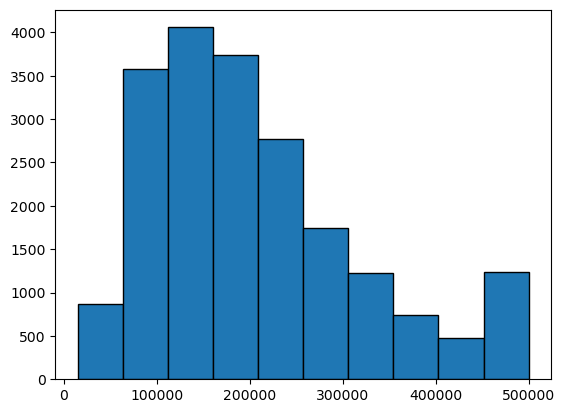

In [127]:
plt.hist(df['median_house_value'], edgecolor = 'black')

Q1: 119500.0
Median: 179700.0
Q3: 264700.0
IQR: 145200.0
Lower: -98300.0
Upper: 482500.0


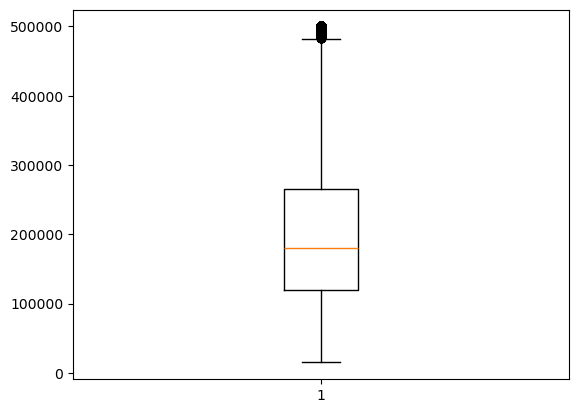

In [128]:
# Get Q1, Median, Q3
Q1 = df['median_house_value'].quantile(0.25)
median = df['median_house_value'].quantile(0.5)
Q3 = df['median_house_value'].quantile(0.75)

# IQR
IQR = Q3 - Q1

# min and max values
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Median:", median)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower:", lower)
print("Upper:", upper)

plt.boxplot(df['median_house_value'])
plt.show()

In [129]:
# outliers
outliers = df[df['median_house_value'] >= upper]

In [130]:
outliers.shape

(1064, 10)

In [131]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


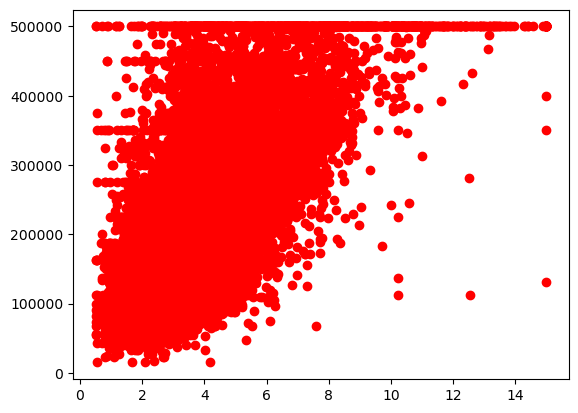

In [132]:
# Examining outliers in median_house_value
plt.scatter(df['median_income'], y = df['median_house_value'], color = 'red')

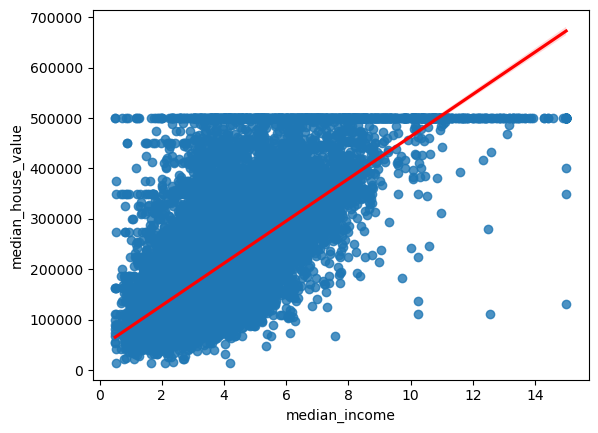

In [133]:
sns.regplot(data = df, x = 'median_income', y = 'median_house_value', line_kws={'color': 'red'})

"""
from the above scatter we can see that the median_house_value contains outliers
which are capped at the range of 500k , the data spread is non-linear,
To handle this outliers, i am applying logrithmic transformation , which reduces
the skewness of the data and compress data spread making it more linear and makes 
values to fit for the model..!
"""
plt.show()

In [134]:
# logirthmic function
df['log_median_house_value'] = np.log(df['median_house_value'])

In [135]:
df['log_median_house_value'].head()

0    13.022764
1    12.789684
2    12.771671
3    12.740517
4    12.743151
Name: log_median_house_value, dtype: float64

In [136]:
df['median_house_value'].head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

<Axes: xlabel='median_income', ylabel='log_median_house_value'>

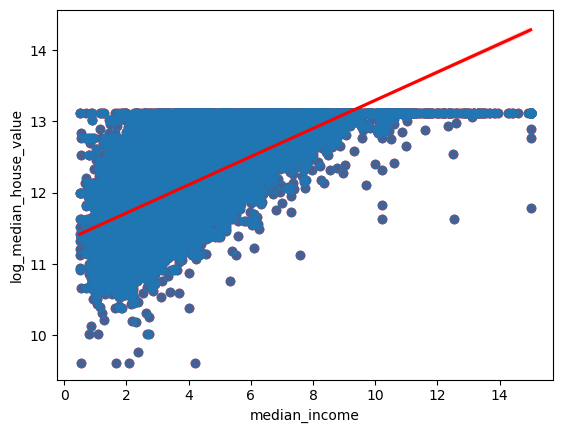

In [137]:
plt.scatter(df['median_income'], y = df['log_median_house_value'], color = 'red')
sns.regplot(data = df, x = 'median_income', y = 'log_median_house_value', line_kws={'color': 'red'})

# Note : Log transformation improves distribution but does not fix artificial limits in data
# Ceiling Effect (or Saturation) : Due to capping, the model may fail to learn the true relationship between income and house prices at higher ranges

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   longitude               20433 non-null  float64 
 1   latitude                20433 non-null  float64 
 2   housing_median_age      20433 non-null  float64 
 3   total_rooms             20433 non-null  float64 
 4   total_bedrooms          20433 non-null  float64 
 5   population              20433 non-null  float64 
 6   households              20433 non-null  float64 
 7   median_income           20433 non-null  float64 
 8   median_house_value      20433 non-null  float64 
 9   ocean_proximity         20433 non-null  category
 10  log_median_house_value  20433 non-null  float64 
dtypes: category(1), float64(10)
memory usage: 1.7 MB


In [139]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,log_median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,13.022764
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,12.789684
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,12.771671
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,12.740517
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,12.743151


In [140]:
df[['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households']] = df[['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households']].astype('int64')

In [141]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,log_median_house_value
0,-122.23,37.88,41,880,129,322,126,8.3252,452600.0,NEAR BAY,13.022764
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500.0,NEAR BAY,12.789684
2,-122.24,37.85,52,1467,190,496,177,7.2574,352100.0,NEAR BAY,12.771671
3,-122.25,37.85,52,1274,235,558,219,5.6431,341300.0,NEAR BAY,12.740517
4,-122.25,37.85,52,1627,280,565,259,3.8462,342200.0,NEAR BAY,12.743151


1. Median Income

<Axes: xlabel='median_income', ylabel='Density'>

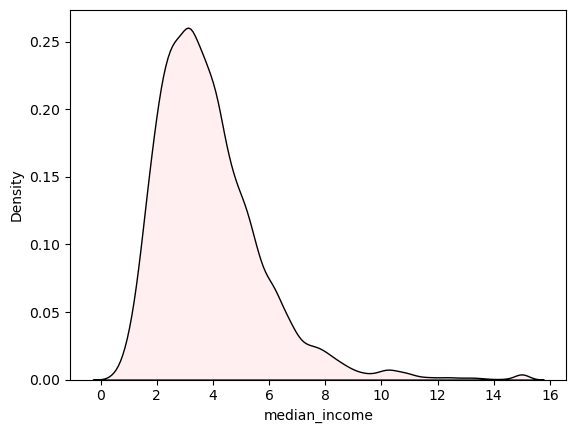

In [142]:
# Distribution of Median Age => Log Normal Distribution
sns.kdeplot(data = df, x = 'median_income',fill = True, color = 'pink', edgecolor = 'black')

<Axes: xlabel='housing_median_age', ylabel='median_income'>

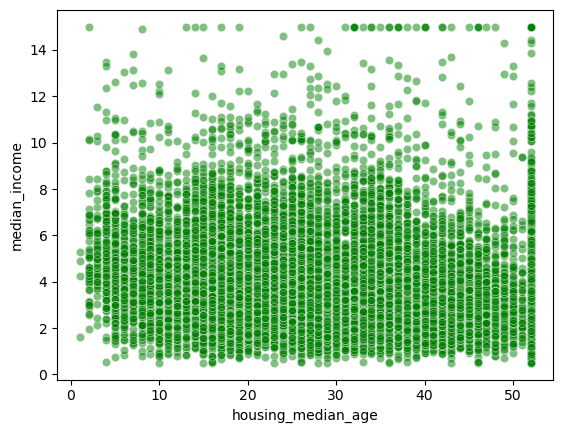

In [143]:
sns.scatterplot(data = df, x = 'housing_median_age', y = 'median_income', color = 'green', alpha = 0.5)

/tmp/ipykernel_93182/1689886424.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data = df, x = 'ocean_proximity', y = 'median_income', ci = None, palette = 'viridis')
/tmp/ipykernel_93182/1689886424.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, x = 'ocean_proximity', y = 'median_income', ci = None, palette = 'viridis')


<Axes: xlabel='ocean_proximity', ylabel='median_income'>

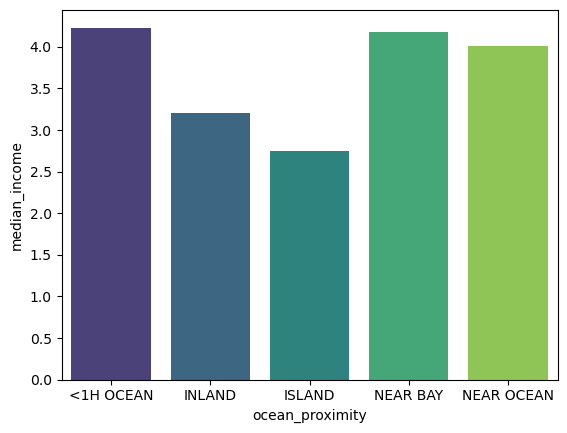

In [144]:
sns.barplot(data = df, x = 'ocean_proximity', y = 'median_income', ci = None, palette = 'viridis')

/tmp/ipykernel_93182/2472133999.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ocean_proximity')['median_income'].sum().plot(kind = 'bar', edgecolor = '#673147', )


'\nIncome varies significantly by location, with areas near the ocean (within 1 hour)\nhaving the highest income, while inland areas have lower income levels.\n'

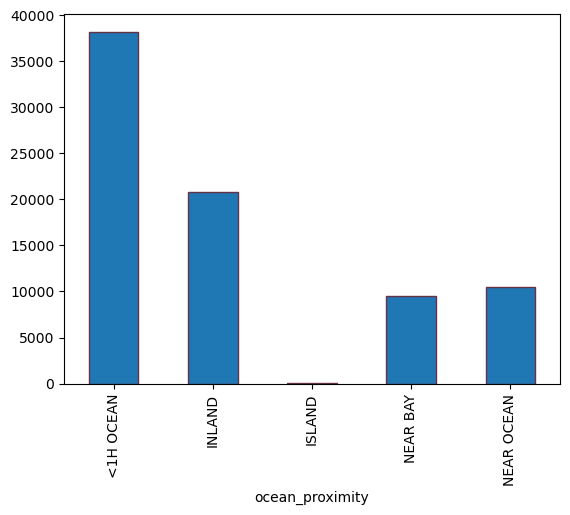

In [145]:
df.groupby('ocean_proximity')['median_income'].sum().plot(kind = 'bar', edgecolor = '#673147', )
"""
Income varies significantly by location, with areas near the ocean (within 1 hour)
having the highest income, while inland areas have lower income levels.
"""

2. Total Rooms

<Axes: xlabel='total_rooms', ylabel='Count'>

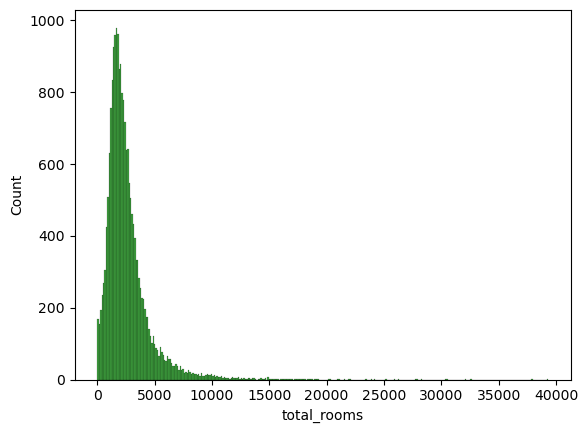

In [146]:
sns.histplot(data = df, x = 'total_rooms', color = 'green')

<Axes: xlabel='total_rooms'>

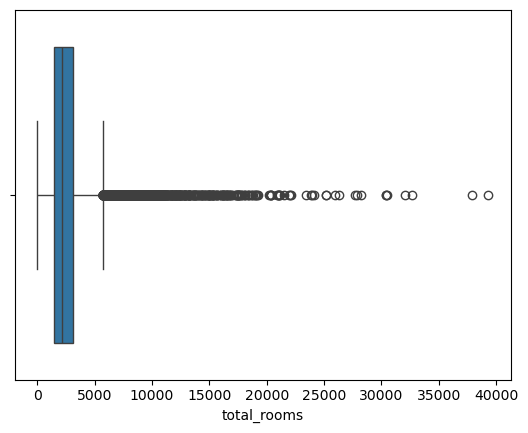

In [147]:
# finding outliers 
sns.boxplot(data = df, x = 'total_rooms',)

In [148]:
# Applying 5 number summary

Q1 = df['total_rooms'].quantile(0.25)
median = df['total_rooms'].median()
Q3 = df['total_rooms'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(Q1)
print(median)
print(Q3)
print(IQR)
print(lower)
print(upper)

1450.0
2127.0
3143.0
1693.0
-1089.5
5682.5


In [149]:
# 6% of the district in california have  total rooms more than upper limit value , so they are considered as outliers
df[df['total_rooms'] > upper].shape

(1290, 11)

'\nSince there are less number of districts in island, average total_room value is less\n'

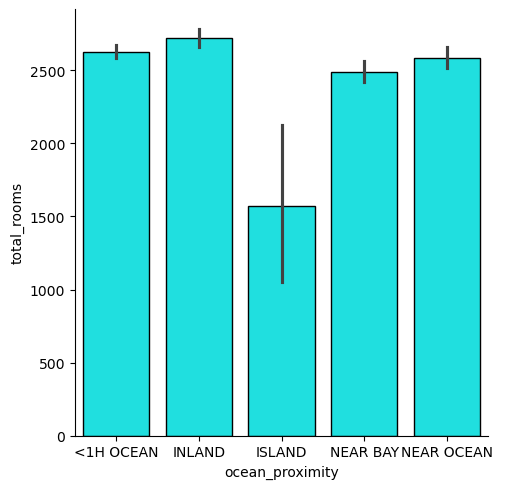

In [150]:
# average of total_rooms per ocean_proximity category

sns.catplot(data = df, x = 'ocean_proximity', y = 'total_rooms', kind = 'bar', color = 'cyan', edgecolor = 'black')

"""
Since there are less number of districts in island, average total_room value is less
"""

3. Total Bedrooms

<Axes: xlabel='total_bedrooms', ylabel='Count'>

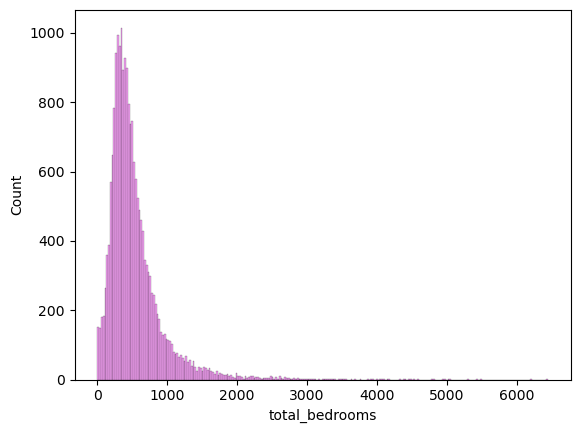

In [151]:
# log normal distribution 
# total_rooms and total_bedrooms are highly correlated
sns.histplot(data = df, x = 'total_bedrooms', color = 'violet')

In [152]:
# median percentage of bedrooms out of total_rooms is 20 %
(df['total_bedrooms'] / df['total_rooms']).median() * 100

20.316243411595593

4. Population

<Axes: xlabel='population', ylabel='Density'>

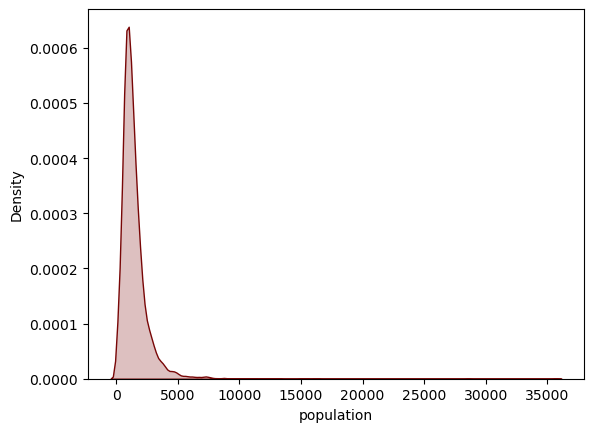

In [153]:
sns.kdeplot(data = df, x = 'population', fill = True, color = '#780606')

In [154]:
# average number of people per household
(df['population'] / df['households']).mean()

3.0715328511910425

<Axes: xlabel='median_income', ylabel='population'>

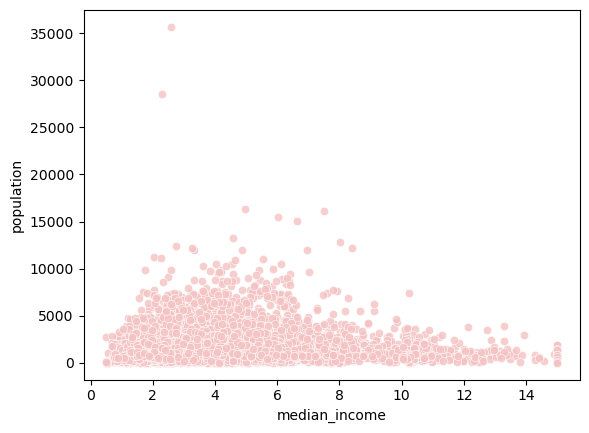

In [155]:
sns.scatterplot(data = df, x = 'median_income', y = 'population', color = '#F4C2C2', alpha = 0.8)

In [156]:
df.sample(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,log_median_house_value
11756,-121.18,38.73,16,1584,264,613,226,6.0302,273100.0,INLAND,12.517593
4671,-118.29,34.05,11,677,370,1143,341,2.3864,350000.0,<1H OCEAN,12.765688
19344,-122.87,38.62,18,2721,557,1667,539,3.1875,176100.0,<1H OCEAN,12.078807


In [157]:
population_per_proximity = df.groupby('ocean_proximity')['population'].count()

/tmp/ipykernel_93182/4275741074.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  population_per_proximity = df.groupby('ocean_proximity')['population'].count()


<Axes: xlabel='ocean_proximity'>

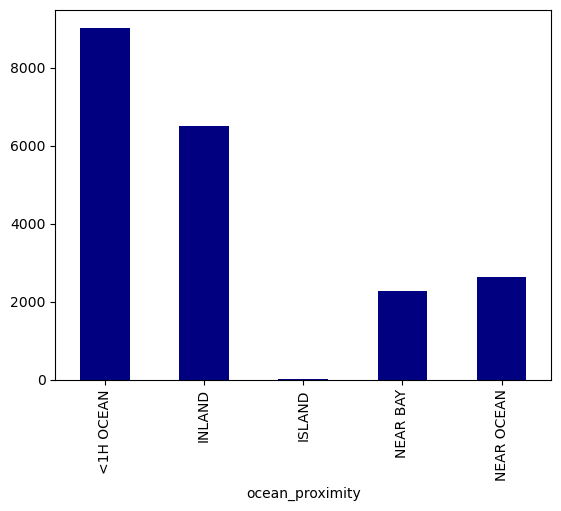

In [158]:
population_per_proximity.plot(kind='bar', colormap='jet')

 5. Households

<Axes: xlabel='households', ylabel='Count'>

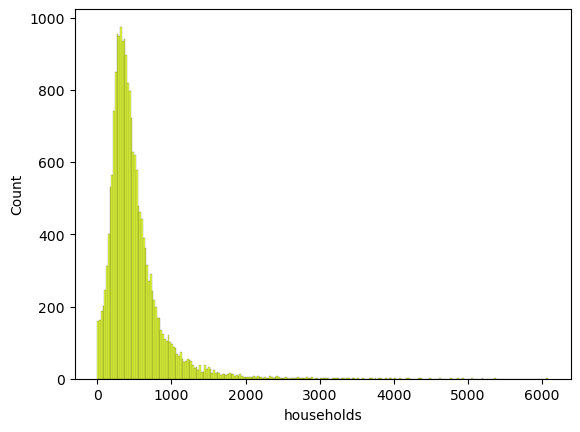

In [159]:
sns.histplot(data = df, x = 'households', color = '#DFFF00')

In [160]:
(df['median_house_value'] / df['households']).mean()

811.2693676058235

In [161]:
df.groupby('ocean_proximity')['households'].count()

/tmp/ipykernel_93182/3183517875.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ocean_proximity')['households'].count()


ocean_proximity
<1H OCEAN     9034
INLAND        6496
ISLAND           5
NEAR BAY      2270
NEAR OCEAN    2628
Name: households, dtype: int64

 * Heatmap based on Correlation

<Axes: >

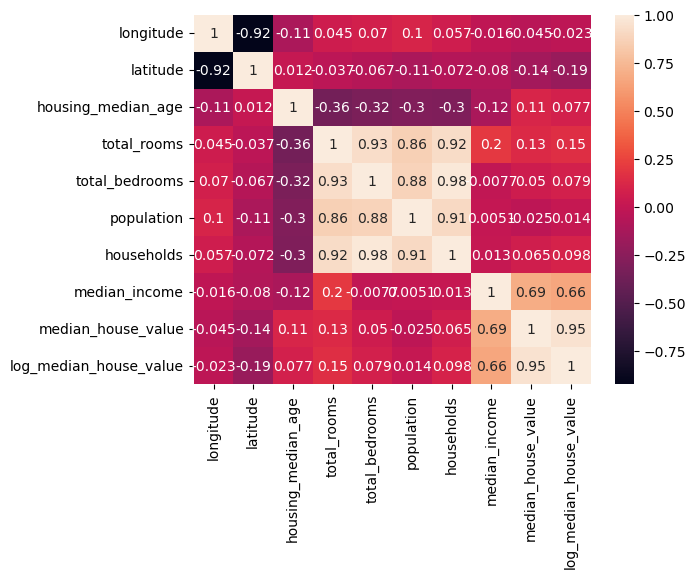

In [162]:
corr = df.corr(numeric_only = True)
sns.heatmap(corr, annot = True)

    Insights

* Prices are right-skewed (many low values, few high values)
Log transformation reduces skewness and compresses large values
* Strong positive relationship between median_income and house price
* Relationship becomes more linear after log transformation
* Dataset has price cap at 500,000
* After log transformation, capped values appear around ~13
* Capped values create a ceiling/saturation effect at higher income levels
* Capped values appear as outliers using the IQR method
* These outliers are valid high-value houses, not noise
* Removing these values would lead to loss of important information
* Model may underestimate high-value houses due to capping
* total_rooms, population, and households are misleading individually
These features require transformation (ratios) for better insights
Location features (latitude, longitude, ocean_proximity) significantly influence house prices